<a href="https://colab.research.google.com/github/chitransh2573bbafai25-pixel/customer-churn-prediction-ml-pipeline/blob/main/anomalies_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

In [ ]:
# set the random seed for reproducibility
np.random.seed(42)

In [ ]:
# generate normal salary data
normal_salaries = np.random.normal(loc=50000, scale=10000, size=10000)

In [ ]:
# introduce anomalies
anomalies = np.random.uniform(low=200000, high=300000, size=10)
anomalies = np.append(anomalies, np.random.uniform(low=10000, high=20000, size=10))

In [ ]:
# combine normal salaries and anomalies
salaries = np.append(normal_salaries, anomalies)

In [ ]:
# create a dataframe
df = pd.DataFrame({'salary': salaries})

In [ ]:
# display the first few rows of the dataset
df.head(10)

,salary
0,54967.141530
1,48617.356988
2,56476.885381
3,65230.298564
4,47658.466253
5,47658.630431
6,65792.128155
7,57674.347292
8,45305.256141
9,55425.600436


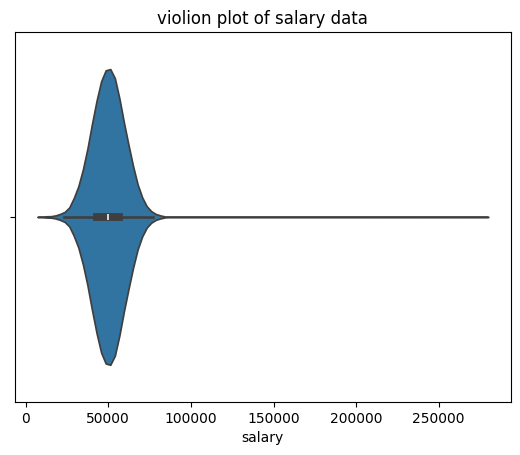

In [ ]:
sns.violinplot(x=df['salary'])
plt.title('violion plot of salary data')
plt.show()

In [ ]:
# define and fit the model
model = IsolationForest(n_estimators=100, max_samples='auto', contamination=0.1, max_features=1.0)
model.fit(df[['salary']])

IsolationForest(contamination=0.1)

In [ ]:
#predict anomalies
df['anomaly_score'] = model.predict(df[['salary']])
df['anomaly'] = df['anomaly_score'].apply(lambda x: 'anomaly' if x == -1 else 'normal')
df.head(10)

,salary,anomaly_score,anomaly_label,anomaly
0,54967.141530,1,1,normal
1,48617.356988,1,1,normal
2,56476.885381,1,1,normal
3,65230.298564,1,1,normal
4,47658.466253,1,1,normal
5,47658.630431,1,1,normal
6,65792.128155,1,1,normal
7,57674.347292,1,1,normal
8,45305.256141,1,1,normal
9,55425.600436,1,1,normal


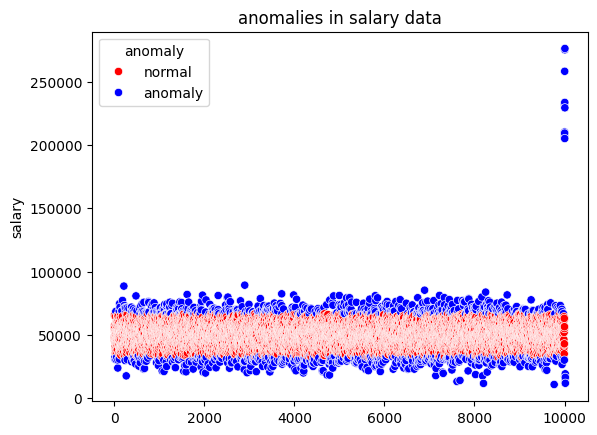

In [ ]:
#visualize anomalies
sns.scatterplot(x=range(len(df)), y='salary', hue='anomaly', data=df, palette=['red', 'blue'])
plt.title('anomalies in salary data')
plt.show()